In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Load the datasset

In [50]:
df = pd.read_csv("messy_data.csv")
df.head()

,Age,Attrition,Department,EmployeeNumber,Gender,JobRole,YearsAtCompany,MonthlyIncome,PerformanceRating
0,50.0,NO,RESEARCH & DEVELOPMENT,1539.0,MALE,RESEARCH DIRECTOR,NaN,14411.0,3.0
1,31.0,NAN,RESEARCH & DEVELOPMENT,NaN,MALE,research director,2.0,13675.0,NaN
2,NaN,NO,sales,481.0,MALE,SALES EXECUTIVE,NaN,9699.0,3.0
3,45.0,no,RESEARCH & DEVELOPMENT,1195.0,female,research scientist,NaN,NaN,3.0
4,29.0,yes,research & development,1421.0,female,healthcare representative,NaN,7553.0,3.0


chek the info of data

In [28]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1544 entries, 0 to 1543
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                1390 non-null   float64
 1   Attrition          1544 non-null   str    
 2   Department         1544 non-null   str    
 3   EmployeeNumber     1390 non-null   float64
 4   Gender             1544 non-null   str    
 5   JobRole            1544 non-null   str    
 6   YearsAtCompany     1387 non-null   float64
 7   MonthlyIncome      1390 non-null   float64
 8   PerformanceRating  1389 non-null   float64
dtypes: float64(5), str(4)
memory usage: 108.7 KB


chek the null values in data 

In [29]:
df.isnull().sum()

Age                  154
Attrition              0
Department             0
EmployeeNumber       154
Gender                 0
JobRole                0
YearsAtCompany       157
MonthlyIncome        154
PerformanceRating    155
dtype: int64

chek the duplicates

In [46]:
df.duplicated().sum()

np.int64(74)

In [47]:
df[df.duplicated()]

,Age,Attrition,Department,EmployeeNumber,Gender,JobRole,YearsAtCompany,MonthlyIncome,PerformanceRating
130,51.0,yes,RESEARCH & DEVELOPMENT,1081.0,male,RESEARCH SCIENTIST,10.0,2461.0,3.0
143,56.0,YES,research & development,161.0,female,research scientist,5.0,4963.0,3.0
191,30.0,yes,NAN,1017.0,NAN,LABORATORY TECHNICIAN,3.0,2422.0,3.0
204,36.0,NO,human resources,829.0,male,human resources,NaN,2143.0,3.0
316,33.0,yes,RESEARCH & DEVELOPMENT,328.0,FEMALE,laboratory technician,9.0,2707.0,4.0
...,...,...,...,...,...,...,...,...,...
1477,56.0,no,research & development,112.0,male,nan,6.0,7260.0,3.0
1479,41.0,nan,sales,625.0,female,manager,18.0,16595.0,3.0
1488,39.0,no,SALES,182.0,FEMALE,sales executive,15.0,5902.0,NaN
1501,NaN,nan,RESEARCH & DEVELOPMENT,1666.0,NAN,RESEARCH DIRECTOR,NaN,17603.0,4.0


In [52]:
df.describe()

,Age,EmployeeNumber,YearsAtCompany,MonthlyIncome,PerformanceRating
count,1390.000000,1390.000000,1387.000000,1390.000000,1389.000000
mean,36.851079,1024.743165,7.057678,6549.935252,3.154068
std,9.214748,600.895483,6.170812,4699.061090,0.361144
min,18.000000,1.000000,0.000000,1009.000000,3.000000
25%,30.000000,492.250000,3.000000,2915.500000,3.000000
50%,35.000000,1017.000000,5.000000,4968.500000,3.000000
75%,43.000000,1552.750000,10.000000,8548.000000,3.000000
max,60.000000,2068.000000,40.000000,19973.000000,4.000000


size of the data like how many rows and how many colums are present in data

In [109]:
df.shape

(1544, 9)

cheking the duplicates in employe no.

In [49]:
df['EmployeeNumber'].value_counts().head(10)

EmployeeNumber
1539.0    2
1206.0    2
1640.0    2
1017.0    2
161.0     2
1441.0    2
1969.0    2
590.0     2
306.0     2
1479.0    2
Name: count, dtype: int64

In [53]:
df.nunique()

Age                    43
Attrition               6
Department              8
EmployeeNumber       1323
Gender                  6
JobRole                20
YearsAtCompany         37
MonthlyIncome        1229
PerformanceRating       2
dtype: int64

In [51]:
df.head()

,Age,Attrition,Department,EmployeeNumber,Gender,JobRole,YearsAtCompany,MonthlyIncome,PerformanceRating
0,50.0,NO,RESEARCH & DEVELOPMENT,1539.0,MALE,RESEARCH DIRECTOR,NaN,14411.0,3.0
1,31.0,NAN,RESEARCH & DEVELOPMENT,NaN,MALE,research director,2.0,13675.0,NaN
2,NaN,NO,sales,481.0,MALE,SALES EXECUTIVE,NaN,9699.0,3.0
3,45.0,no,RESEARCH & DEVELOPMENT,1195.0,female,research scientist,NaN,NaN,3.0
4,29.0,yes,research & development,1421.0,female,healthcare representative,NaN,7553.0,3.0


we sow that which kind of values are present in Age column

In [36]:
df["Age"].unique()

array([50., 31., nan, 45., 29., 36., 44., 51., 42., 24., 53., 34., 40.,
       47., 19., 37., 46., 43., 27., 26., 57., 55., 30., 56., 25., 54.,
       32., 38., 41., 23., 60., 35., 39., 28., 33., 20., 48., 49., 52.,
       22., 59., 21., 58., 18.])

we created a histogra of all the numeric colums

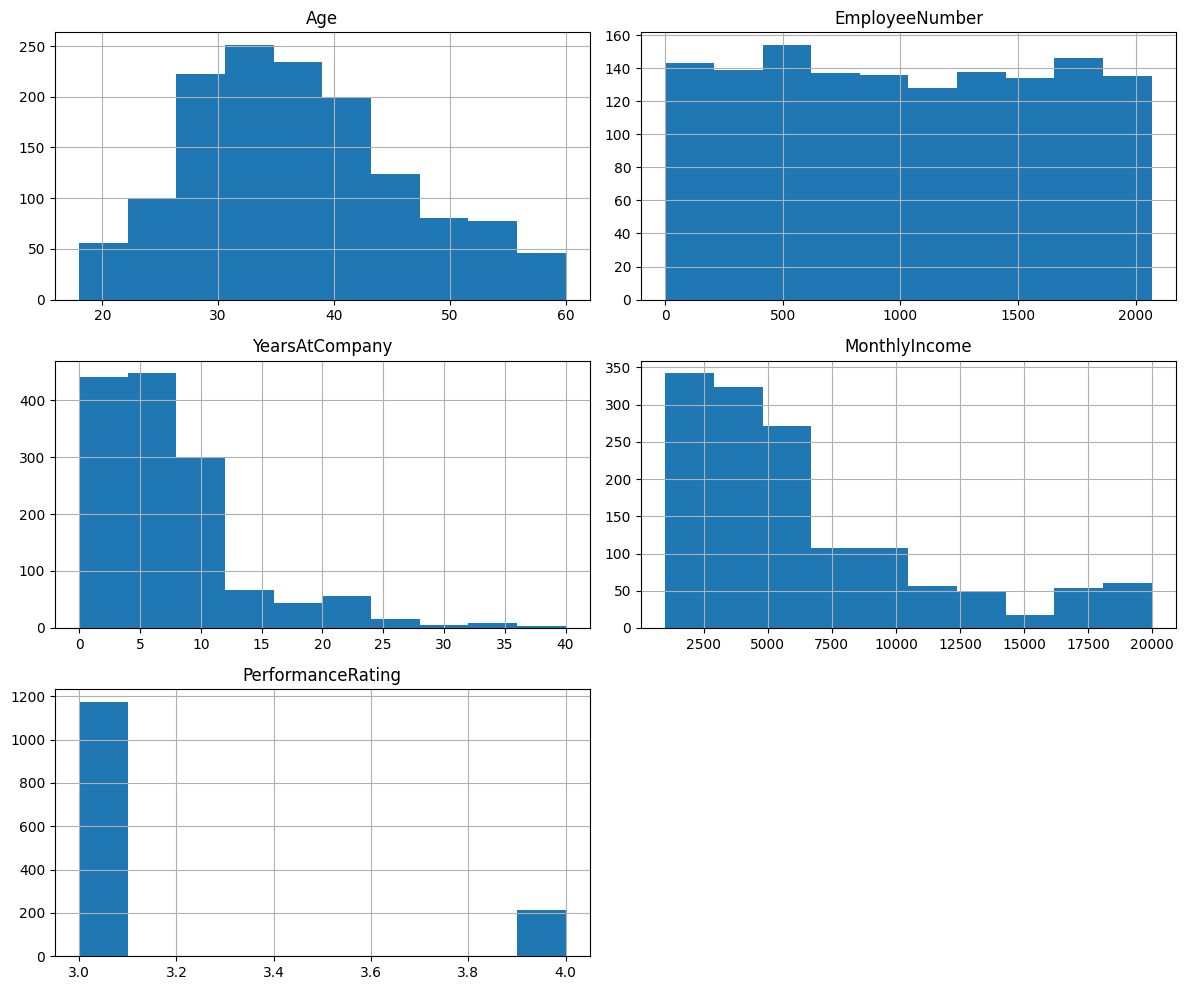

In [55]:
import matplotlib.pyplot as plt

df.hist(figsize=(12,10))
plt.tight_layout()
plt.show()

This chart shows attrition distribution across genders.

Data inconsistency is present (MALE/male, FEMALE/female, NaN), so cleaning is required before final analysis.

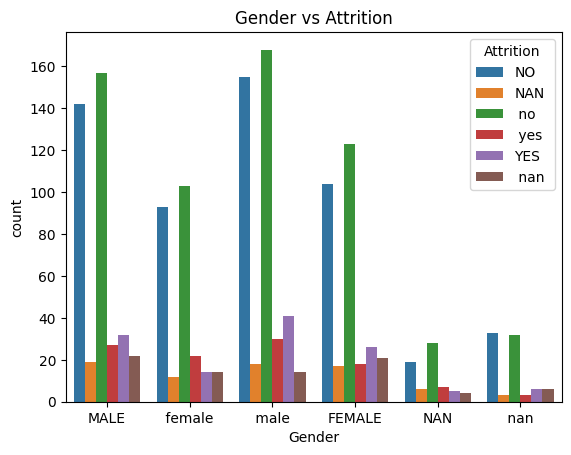

In [56]:
sns.countplot(x="Gender", hue="Attrition", data=df)
plt.title("Gender vs Attrition")
plt.show()

This chart shows the proportion of employees who stayed and left the company.

Most employees have not left the company, but data inconsistency (YES/yes, NO/no, NaN) needs cleaning.

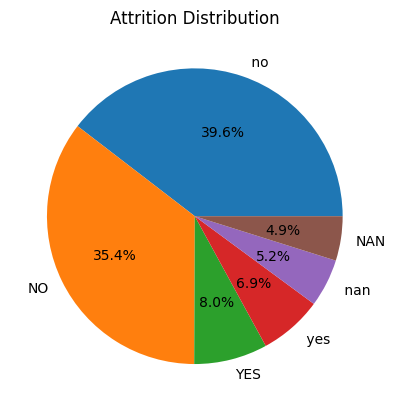

In [57]:
df['Attrition'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title("Attrition Distribution")
plt.ylabel('')
plt.show()

This boxplot shows the distribution of employee experience and highlights outliers.

Most employees have lower years of experience, with some high-value outliers present.

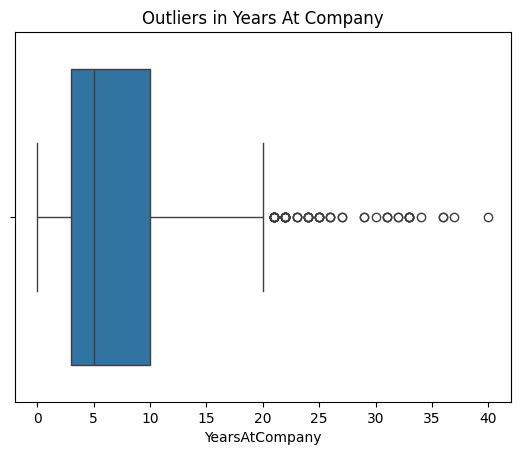

In [60]:
sns.boxplot(x=df['YearsAtCompany'])
plt.title("Outliers in Years At Company")
plt.show()

This scatter plot shows the relationship between years at company and monthly income.

Salary generally increases with experience, but there is high variation across employees.

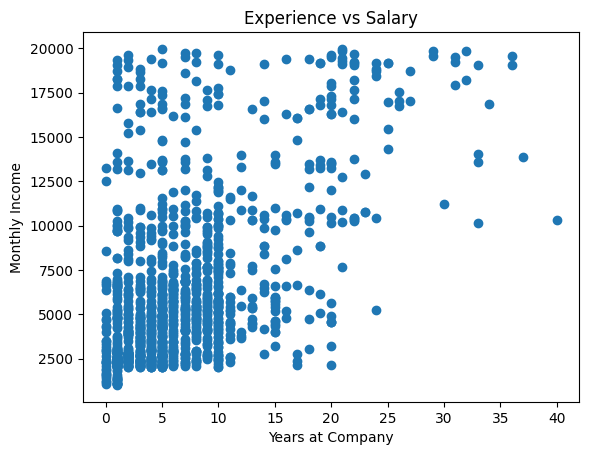

In [61]:
plt.scatter(df['YearsAtCompany'], df['MonthlyIncome'])
plt.xlabel("Years at Company")
plt.ylabel("Monthly Income")
plt.title("Experience vs Salary")
plt.show()

This heatmap shows the correlation between numerical features.

YearsAtCompany and MonthlyIncome have a moderate positive correlation, while most other features show weak relationships.

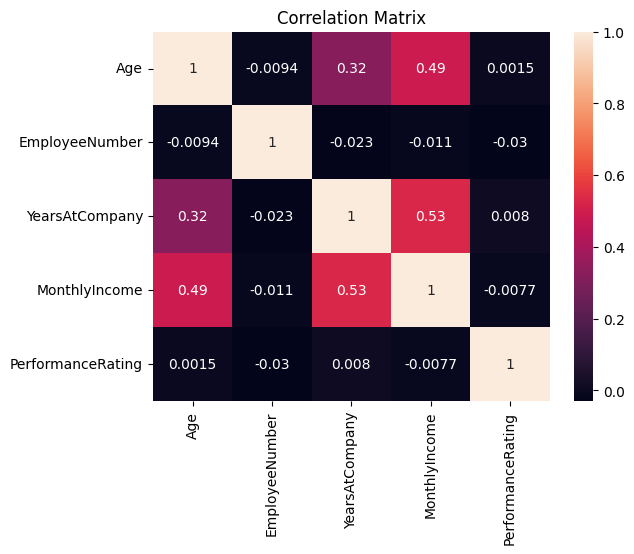

In [62]:
corr = df.select_dtypes(include=['int64','float64']).corr()
sns.heatmap(corr, annot=True)
plt.title("Correlation Matrix")
plt.show()

we created a copy of data before cleaning

In [64]:
df_clean = df.copy()

chek the nulls

In [65]:
df_clean.isnull().sum()

Age                  154
Attrition              0
Department             0
EmployeeNumber       154
Gender                 0
JobRole                0
YearsAtCompany       157
MonthlyIncome        154
PerformanceRating    155
dtype: int64

saw duplicates in employee number

In [66]:
df['EmployeeNumber'].value_counts().head(10)

EmployeeNumber
1539.0    2
1206.0    2
1640.0    2
1017.0    2
161.0     2
1441.0    2
1969.0    2
590.0     2
306.0     2
1479.0    2
Name: count, dtype: int64

remove the duplicates

In [67]:
df_clean = df_clean.drop_duplicates(subset=['EmployeeNumber'])

fill tha missing values in age using median

In [70]:
df_clean['Age'] = df_clean['Age'].fillna(df_clean['Age'].median())

fill tha missing values in years at company using median

In [71]:
df_clean['YearsAtCompany'] = df_clean['YearsAtCompany'].fillna(df_clean['YearsAtCompany'].median())

fill tha missing values in monthaly income using median

In [72]:
df_clean['MonthlyIncome'] = df_clean['MonthlyIncome'].fillna(df_clean['MonthlyIncome'].median())


fill tha missing values in performance rating using median

In [73]:
df_clean['PerformanceRating'] = df_clean['PerformanceRating'].fillna(df_clean['PerformanceRating'].mode()[0])

we chek again but still 1 value is left for filling

In [75]:
df_clean.isnull().sum()

Age                  0
Attrition            0
Department           0
EmployeeNumber       1
Gender               0
JobRole              0
YearsAtCompany       0
MonthlyIncome        0
PerformanceRating    0
dtype: int64

then we perform operation again 

In [76]:
df_clean = df_clean.dropna(subset=['EmployeeNumber'])

now no missing values in the dataset

In [77]:
df_clean.isnull().sum()

Age                  0
Attrition            0
Department           0
EmployeeNumber       0
Gender               0
JobRole              0
YearsAtCompany       0
MonthlyIncome        0
PerformanceRating    0
dtype: int64

we chek which kind of values are prresent in the gender

In [78]:
df_clean['Gender'].unique()

<StringArray>
['MALE', ' female ', ' male ', 'FEMALE', 'NAN', ' nan ']
Length: 6, dtype: str

we use dictionary patter to clear this column

In [79]:
df_clean['Gender'] = df_clean['Gender'].str.strip().str.lower()

df_clean['Gender'] = df_clean['Gender'].replace({
    'male': 'Male',
    'female': 'Female',
    'nan': None
})

fill the misisng woth the help of mode


In [81]:
df_clean['Gender'].fillna(df_clean['Gender'].mode()[0], inplace=True)

/var/folders/xm/3qq098w91x7_29dppzksj0380000gn/T/ipykernel_68711/4237020232.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df_clean['Gender'].fillna(df_clean['Gender'].mode()[0], inplace=True)


0         Male
2         Male
3       Female
4       Female
5         Male
         ...  
1539      Male
1540      Male
1541    Female
1542      Male
1543    Female
Name: Gender, Length: 1323, dtype: object

unique values in Gender column 

In [82]:
df_clean['Gender'].unique()

array(['Male', 'Female', None], dtype=object)

In [88]:
df_clean = df_clean.dropna(subset=['Gender'])

solving Outlires

In [90]:
Q1 = df_clean['YearsAtCompany'].quantile(0.25)
Q3 = df_clean['YearsAtCompany'].quantile(0.75)
IQR = Q3 - Q1

In [91]:
df_clean = df_clean[
    (df_clean['YearsAtCompany'] >= Q1 - 1.5 * IQR) &
    (df_clean['YearsAtCompany'] <= Q3 + 1.5 * IQR)
]

stiil outlires are present 

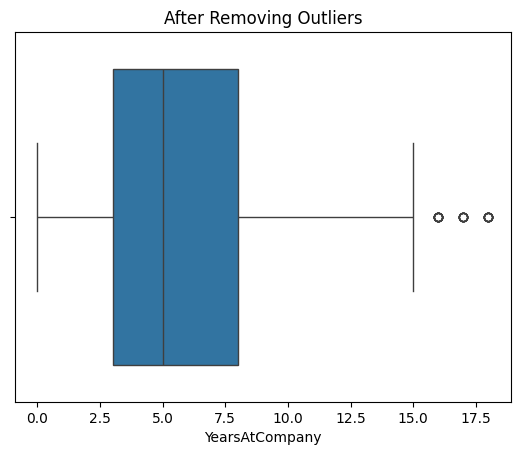

In [94]:
sns.boxplot(x=df_clean['YearsAtCompany'])
plt.title("After Removing Outliers")
plt.show()

finla touch for outlires 

In [95]:
Q1 = df_clean['YearsAtCompany'].quantile(0.25)
Q3 = df_clean['YearsAtCompany'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df_clean['YearsAtCompany'] = df_clean['YearsAtCompany'].clip(lower, upper)

all outlires are removed

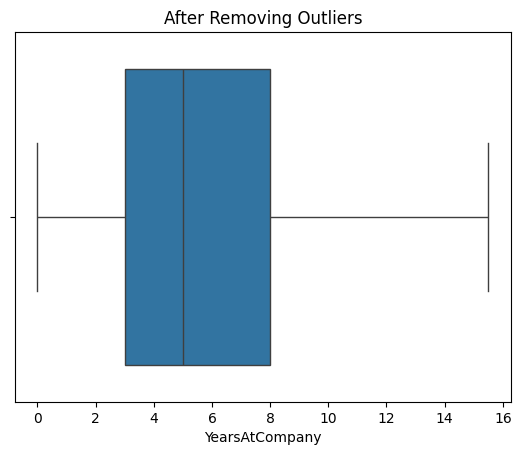

In [96]:
sns.boxplot(x=df_clean['YearsAtCompany'])
plt.title("After Removing Outliers")
plt.show()

all the data is clean now

In [ ]:
df_clean.info()

<class 'pandas.DataFrame'>
Index: 1111 entries, 0 to 1543
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                1111 non-null   float64
 1   Attrition          1111 non-null   str    
 2   Department         1111 non-null   str    
 3   EmployeeNumber     1111 non-null   float64
 4   Gender             1111 non-null   object 
 5   JobRole            1111 non-null   str    
 6   YearsAtCompany     1111 non-null   float64
 7   MonthlyIncome      1111 non-null   float64
 8   PerformanceRating  1111 non-null   float64
dtypes: float64(5), object(1), str(3)
memory usage: 86.8+ KB


final check of data
0 nulls are present

In [99]:
df_clean.isnull().sum()

Age                  0
Attrition            0
Department           0
EmployeeNumber       0
Gender               0
JobRole              0
YearsAtCompany       0
MonthlyIncome        0
PerformanceRating    0
dtype: int64

no duplicates values are present

In [100]:
df_clean.duplicated().sum()

np.int64(0)

comparison 

<Axes: xlabel='Department', ylabel='count'>

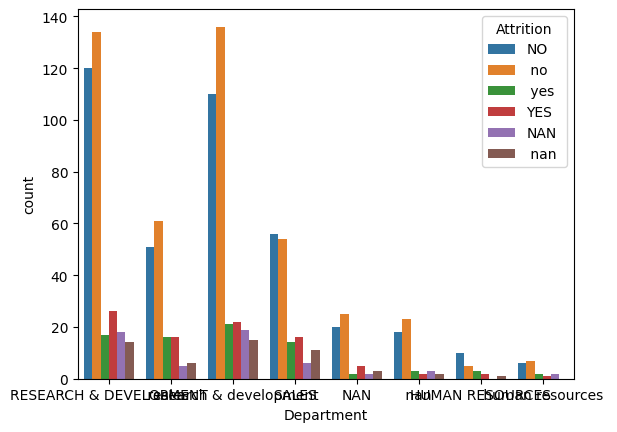

In [101]:
sns.countplot(x='Department', hue='Attrition', data=df_clean)

visula representation

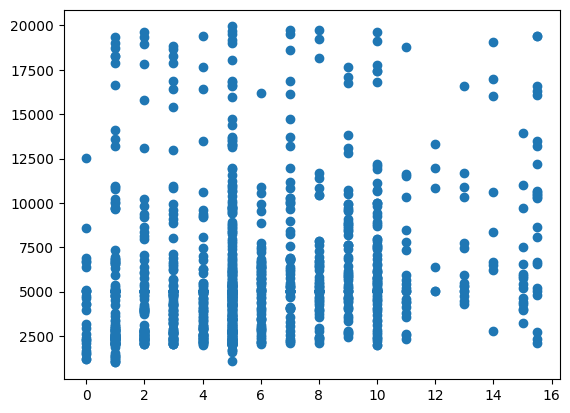

In [102]:
import matplotlib.pyplot as plt
plt.scatter(df_clean['YearsAtCompany'], df_clean['MonthlyIncome'])

(array([ 21., 229.,  97., 141., 239.,  92.,  53.,  33.,  31.,  45.,  29.,
         13.,  11.,  13.,   3.,   6.,  17.,   8.,  11.,  19.]),
 array([ 1009. ,  1955.7,  2902.4,  3849.1,  4795.8,  5742.5,  6689.2,
         7635.9,  8582.6,  9529.3, 10476. , 11422.7, 12369.4, 13316.1,
        14262.8, 15209.5, 16156.2, 17102.9, 18049.6, 18996.3, 19943. ]),
 <BarContainer object of 20 artists>)

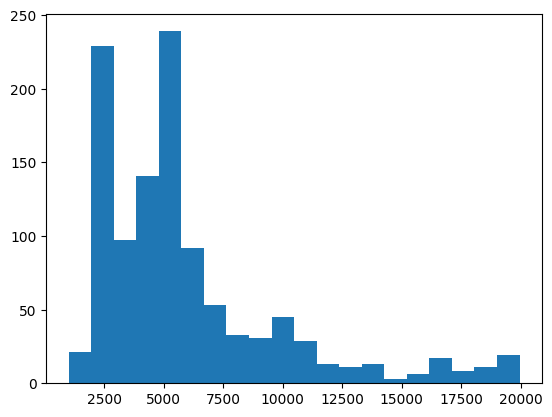

In [103]:
plt.hist(df_clean['MonthlyIncome'], bins=20)

In [106]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X = pd.get_dummies(df.drop("Attrition", axis=1), drop_first=True)
y = df["Attrition"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

new cleand file save for data visualization

In [111]:
df.to_csv("HR_Attrition_Cleaned.csv", index=False)